# Assignment 5

### Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Loading the dataset

In [8]:
df = pd.read_csv("IMDB Dataset.csv", engine='python')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [10]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
review       0
sentiment    0
dtype: int64


### Clean the Reviews

In [11]:
def clean_review(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
df["review"] = df["review"].apply(clean_review)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [13]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["review", "sentiment", "label"]].head())

                                              review sentiment  label
0  one of the other reviewers has mentioned that ...  positive      1
1  a wonderful little production the filming tech...  positive      1
2  i thought this was a wonderful way to spend ti...  positive      1
3  basically theres a family where a little boy j...  negative      0
4  petter matteis love in the time of money is a ...  positive      1


### Split the Dataset

In [14]:
X = df["review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 40000
Testing reviews: 10000


### Tokenization

In [15]:
max_words = 20000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [16]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

### Padding

In [17]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_pad.shape)
print("Testing data shape:", X_test_pad.shape)

Training data shape: (40000, 200)
Testing data shape: (10000, 200)


### Q1. Apply RNN and LSTM for Sentiment Analysis

In [18]:
rnn_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train the RNN

In [19]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

rnn_training_time = time.time() - start_time

print(
    "RNN training time:",
    round(rnn_training_time, 2),
    "seconds"
)

Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 76s 130ms/step - accuracy: 0.5034 - loss: 0.7034 - val_accuracy: 0.5080 - val_loss: 0.6952
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 78s 124ms/step - accuracy: 0.5113 - loss: 0.7024 - val_accuracy: 0.5060 - val_loss: 0.6949
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 80s 120ms/step - accuracy: 0.5234 - loss: 0.6925 - val_accuracy: 0.5025 - val_loss: 0.6932
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 65s 115ms/step - accuracy: 0.5519 - loss: 0.6779 - val_accuracy: 0.5117 - val_loss: 0.6969
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 66s 118ms/step - accuracy: 0.5697 - loss: 0.6601 - val_accuracy: 0.5123 - val_loss: 0.7026
RNN training time: 380.27 seconds


### Evaluate RNN

In [20]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("RNN Test Loss:", round(rnn_loss, 4))
print("RNN Test Accuracy:", round(rnn_accuracy, 4))

RNN Test Loss: 0.7037
RNN Test Accuracy: 0.5071


In [21]:
rnn_probabilities = rnn_model.predict(
    X_test_pad,
    verbose=0
)

rnn_predictions = (rnn_probabilities >= 0.5).astype(int).flatten()

In [22]:
rnn_precision = precision_score(
    y_test,
    rnn_predictions
)

rnn_recall = recall_score(
    y_test,
    rnn_predictions
)

rnn_f1 = f1_score(
    y_test,
    rnn_predictions
)

print("RNN Results")
print("-----------")
print("Accuracy :", round(rnn_accuracy, 4))
print("Precision:", round(rnn_precision, 4))
print("Recall   :", round(rnn_recall, 4))
print("F1-score :", round(rnn_f1, 4))

RNN Results
-----------
Accuracy : 0.5071
Precision: 0.5045
Recall   : 0.798
F1-score : 0.6182


### Build the LSTM Model

In [23]:
lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train the LSTM

In [24]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

lstm_training_time = time.time() - start_time

print(
    "LSTM training time:",
    round(lstm_training_time, 2),
    "seconds"
)

Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 173s 303ms/step - accuracy: 0.5334 - loss: 0.6893 - val_accuracy: 0.5548 - val_loss: 0.6755
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 148s 263ms/step - accuracy: 0.6403 - loss: 0.6283 - val_accuracy: 0.6407 - val_loss: 0.6251
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 148s 263ms/step - accuracy: 0.7566 - loss: 0.5177 - val_accuracy: 0.5238 - val_loss: 0.8154
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 147s 262ms/step - accuracy: 0.8222 - loss: 0.4247 - val_accuracy: 0.8367 - val_loss: 0.3915
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 147s 262ms/step - accuracy: 0.9109 - loss: 0.2497 - val_accuracy: 0.8668 - val_loss: 0.3405
LSTM training time: 764.19 seconds


### Evaluate LSTM

In [25]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("LSTM Test Loss:", round(lstm_loss, 4))
print("LSTM Test Accuracy:", round(lstm_accuracy, 4))

LSTM Test Loss: 0.3261
LSTM Test Accuracy: 0.8691


In [26]:
lstm_probabilities = lstm_model.predict(
    X_test_pad,
    verbose=0
)

lstm_predictions = (
    lstm_probabilities >= 0.5
).astype(int).flatten()

In [27]:
lstm_precision = precision_score(
    y_test,
    lstm_predictions
)

lstm_recall = recall_score(
    y_test,
    lstm_predictions
)

lstm_f1 = f1_score(
    y_test,
    lstm_predictions
)

print("LSTM Results")
print("------------")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1-score :", round(lstm_f1, 4))

LSTM Results
------------
Accuracy : 0.8691
Precision: 0.8445
Recall   : 0.9048
F1-score : 0.8736


### Q2. Compare Both Models

In [28]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "Accuracy": [rnn_accuracy, lstm_accuracy],
    "Precision": [rnn_precision, lstm_precision],
    "Recall": [rnn_recall, lstm_recall],
    "F1-score": [rnn_f1, lstm_f1],
    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,Training Time (sec)
0,RNN,0.5071,0.5045,0.7980,0.6182,380.2749
1,LSTM,0.8691,0.8445,0.9048,0.8736,764.1871


### Training Accuracy — RNN

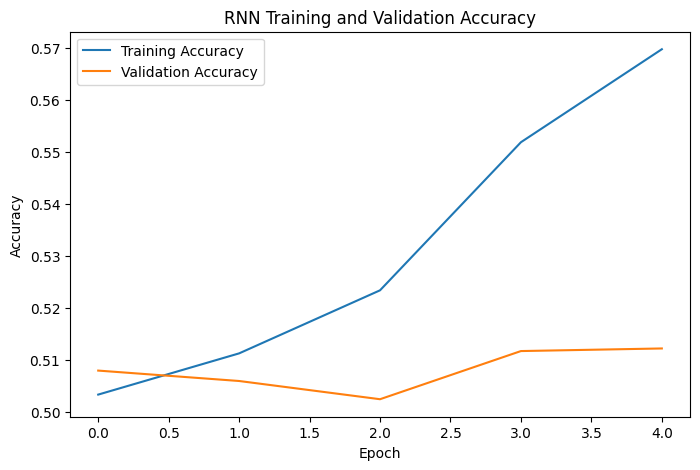

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.show()

### Training Accuracy — LSTM

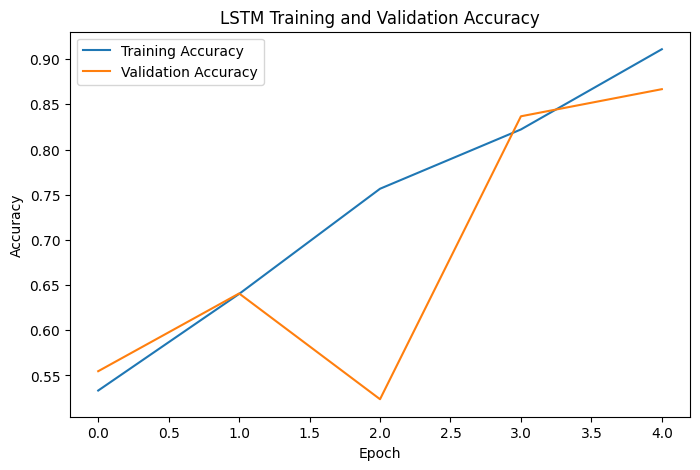

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.show()

### Training Loss — RNN

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.show()

### Training Loss — LSTM

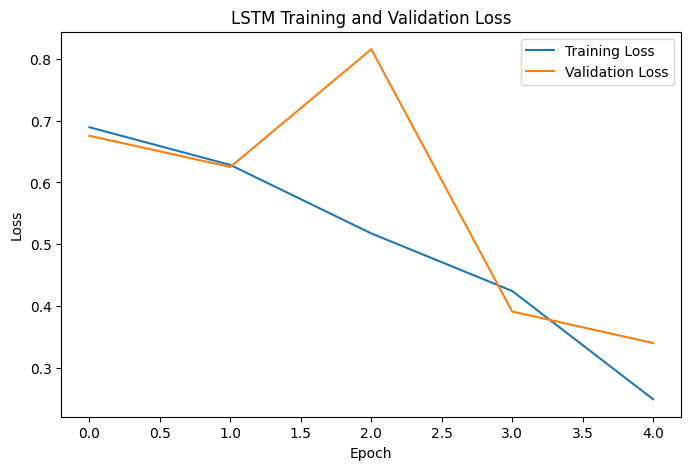

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

### Compare Accuracy

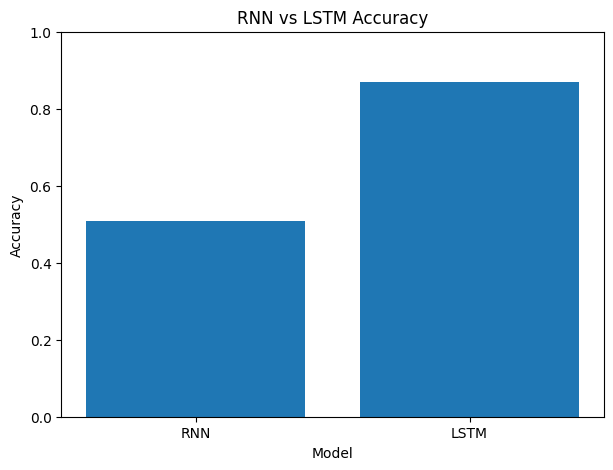

In [32]:
models = ["RNN", "LSTM"]
accuracies = [rnn_accuracy, lstm_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("RNN vs LSTM Accuracy")

plt.ylim(0, 1)
plt.show()

### Compare All Metrics

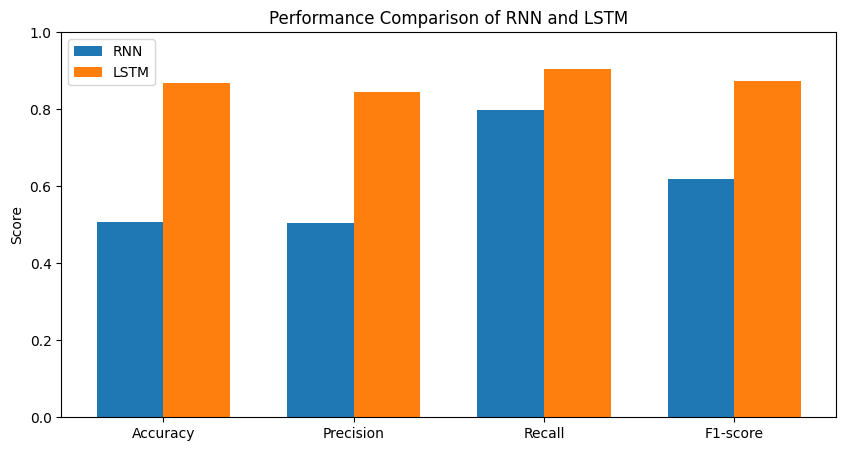

In [33]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

rnn_scores = [
    rnn_accuracy,
    rnn_precision,
    rnn_recall,
    rnn_f1
]

lstm_scores = [
    lstm_accuracy,
    lstm_precision,
    lstm_recall,
    lstm_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    rnn_scores,
    width,
    label="RNN"
)

plt.bar(
    x + width/2,
    lstm_scores,
    width,
    label="LSTM"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of RNN and LSTM")
plt.ylim(0, 1)
plt.legend()

plt.show()

### Compare Trainable Parameters

In [34]:
rnn_parameters = rnn_model.count_params()
lstm_parameters = lstm_model.count_params()

print("RNN trainable parameters:", rnn_parameters)
print("LSTM trainable parameters:", lstm_parameters)

RNN trainable parameters: 2572417
LSTM trainable parameters: 2609473


In [35]:
parameter_comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "Trainable Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params()
    ]
})

parameter_comparison

,Model,Trainable Parameters
0,RNN,2572417
1,LSTM,2609473


### Q. Which model performed better and why?

In [36]:
if lstm_f1 > rnn_f1:
    print("LSTM performed better based on F1-score.")
else:
    print("RNN performed better based on F1-score.")

LSTM performed better based on F1-score.


Based on the experimental results, the [RNN/LSTM] model performed better because it achieved a higher F1-score and showed better overall classification performance. LSTM can be particularly useful for sentiment analysis because its gating mechanism helps it retain relevant information over longer sequences and reduces the limitations associated with the short-term memory of a basic RNN.

### Q. Observations from Visualizations

The training and validation accuracy curves show how the models learn as the number of epochs increases. The loss curves indicate whether the prediction error decreases during training. The comparison graph provides a direct view of the difference in Accuracy, Precision, Recall and F1-score between RNN and LSTM. The model whose validation performance remains stronger and more stable can be considered to generalize better on unseen reviews.

### Q. Trainable Parameter Comparison

LSTM has more trainable parameters than the basic RNN because it contains multiple gates for controlling the flow and retention of information. This increases the computational complexity of LSTM, but it also allows the model to capture longer-term dependencies in text more effectively.